[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/EMQA/blob/main/EMQA_spread_trading/EMQA_spread_trading.ipynb)

# EMQA_spread_trading
Spread trading in energy markets: crack spread (oil vs gasoline), spark spread (gas vs electricity), and dark spread (coal vs electricity). Key profitability indicators for refiners and power generators.
**Output:** `spread_trading.pdf`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.transparent': True,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'figure.figsize': (12, 6),
})

COLORS = {
    'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32',
    'orange': '#E67E22', 'purple': '#8E44AD', 'gray': '#808080',
    'cyan': '#00BCD4', 'amber': '#B5853F'
}

def save_fig(fig, name):
    fig.savefig(name, bbox_inches='tight', transparent=True, dpi=300,
                facecolor='none', edgecolor='none')
    print(f"Saved: {name}")
    if name.endswith('.pdf'):
        png_name = name[:-4] + '.png'
        fig.savefig(png_name, bbox_inches='tight', transparent=True, dpi=300,
                    facecolor='none', edgecolor='none')
        print(f"Saved: {png_name}")

In [2]:
import yfinance as yf

def fetch(ticker, start='2020-01-01', end='2025-12-31'):
    """Fetch price data from Yahoo Finance"""
    d = yf.download(ticker, start=start, end=end, progress=False)
    if isinstance(d.columns, pd.MultiIndex):
        return d['Close'].squeeze().dropna()
    return d['Close'].dropna()

In [3]:
# Fetch energy prices for crack spread calculation
# Brent Crude Oil
brent = fetch('BZ=F')
# RBOB Gasoline
gasoline = fetch('RB=F')
# Heating Oil (proxy for diesel)
heating_oil = fetch('HO=F')
# Natural Gas
nat_gas = fetch('NG=F')

print(f"Brent: {len(brent)} observations")
print(f"Gasoline: {len(gasoline)} observations")
print(f"Heating Oil: {len(heating_oil)} observations")
print(f"Natural Gas: {len(nat_gas)} observations")

Brent: 1510 observations
Gasoline: 1510 observations
Heating Oil: 1510 observations
Natural Gas: 1510 observations


In [4]:
# Calculate Crack Spreads
# Align all series to common dates
common = brent.index.intersection(gasoline.index).intersection(heating_oil.index)
brent_aligned = brent.loc[common]
gasoline_aligned = gasoline.loc[common]
heating_oil_aligned = heating_oil.loc[common]

# 1:1 Crack Spread: Gasoline ($/gal * 42 gal/bbl) - Crude ($/bbl)
crack_1_1 = gasoline_aligned * 42 - brent_aligned

# 3:2:1 Crack Spread: 2 bbl gasoline + 1 bbl heating oil - 3 bbl crude
# (2 * gasoline * 42 + 1 * heating_oil * 42 - 3 * crude) / 3
crack_3_2_1 = (2 * gasoline_aligned * 42 + heating_oil_aligned * 42 - 3 * brent_aligned) / 3

print(f"\n1:1 Crack Spread (Gasoline):")
print(f"  Mean: ${crack_1_1.mean():.2f}/bbl")
print(f"  Std: ${crack_1_1.std():.2f}")
print(f"  Current: ${crack_1_1.iloc[-1]:.2f}")

print(f"\n3:2:1 Crack Spread:")
print(f"  Mean: ${crack_3_2_1.mean():.2f}/bbl")
print(f"  Std: ${crack_3_2_1.std():.2f}")
print(f"  Current: ${crack_3_2_1.iloc[-1]:.2f}")


1:1 Crack Spread (Gasoline):
  Mean: $17.83/bbl
  Std: $9.85
  Current: $10.36

3:2:1 Crack Spread:
  Mean: $20.91/bbl
  Std: $10.23
  Current: $16.38


In [5]:
# Generate simulated electricity prices for spark spread
# (Since electricity futures are not easily available on Yahoo Finance)

np.random.seed(42)

# Create electricity price series correlated with natural gas
nat_gas_common = nat_gas.reindex(common, method='ffill').dropna()
common2 = nat_gas_common.index

# Electricity price model: base + gas_component + noise + seasonality
base_price = 45  # Base electricity price ($/MWh)
heat_rate = 7.5  # MMBtu/MWh (typical CCGT efficiency)

# Seasonal component (higher in summer/winter)
days = np.arange(len(common2))
seasonality = 10 * np.sin(2 * np.pi * days / 365) + 5 * np.sin(4 * np.pi * days / 365)

# Random component
noise = np.random.normal(0, 8, len(common2))

# Electricity price = base + gas * heat_rate + seasonal + noise
elec_price = base_price + nat_gas_common.values * heat_rate + seasonality + noise
elec_price = np.maximum(elec_price, 10)  # Floor at $10/MWh
elec_series = pd.Series(elec_price, index=common2)

# Spark Spread = Electricity - Gas * Heat Rate
spark_spread = elec_series - nat_gas_common * heat_rate

print(f"\nSpark Spread (Heat Rate = {heat_rate} MMBtu/MWh):")
print(f"  Mean: ${spark_spread.mean():.2f}/MWh")
print(f"  Std: ${spark_spread.std():.2f}")
print(f"  Current: ${spark_spread.iloc[-1]:.2f}")


Spark Spread (Heat Rate = 7.5 MMBtu/MWh):
  Mean: $45.64/MWh
  Std: $11.14
  Current: $69.26


In [6]:
# Dark Spread simulation (Coal to Electricity)
# Coal price ~ correlated with gas but lower and less volatile

coal_base = 80  # $/ton
coal_heat_rate = 10.5  # MMBtu/MWh (typical coal plant efficiency)
coal_heat_content = 20  # MMBtu/ton

# Simulate coal price (less volatile than gas)
coal_returns = np.random.normal(0.0001, 0.01, len(common2))
coal_price = coal_base * np.cumprod(1 + coal_returns)
coal_series = pd.Series(coal_price, index=common2)

# Dark Spread = Electricity - Coal * (Heat Rate / Heat Content)
# Convert coal to $/MWh: ($/ton) * (MMBtu/MWh) / (MMBtu/ton)
coal_cost_per_mwh = coal_series * coal_heat_rate / coal_heat_content
dark_spread = elec_series - coal_cost_per_mwh

print(f"\nDark Spread (Coal Heat Rate = {coal_heat_rate} MMBtu/MWh):")
print(f"  Mean: ${dark_spread.mean():.2f}/MWh")
print(f"  Std: ${dark_spread.std():.2f}")
print(f"  Current: ${dark_spread.iloc[-1]:.2f}")


Dark Spread (Coal Heat Rate = 10.5 MMBtu/MWh):
  Mean: $23.71/MWh
  Std: $16.90
  Current: $47.55


Saved: spread_trading.pdf


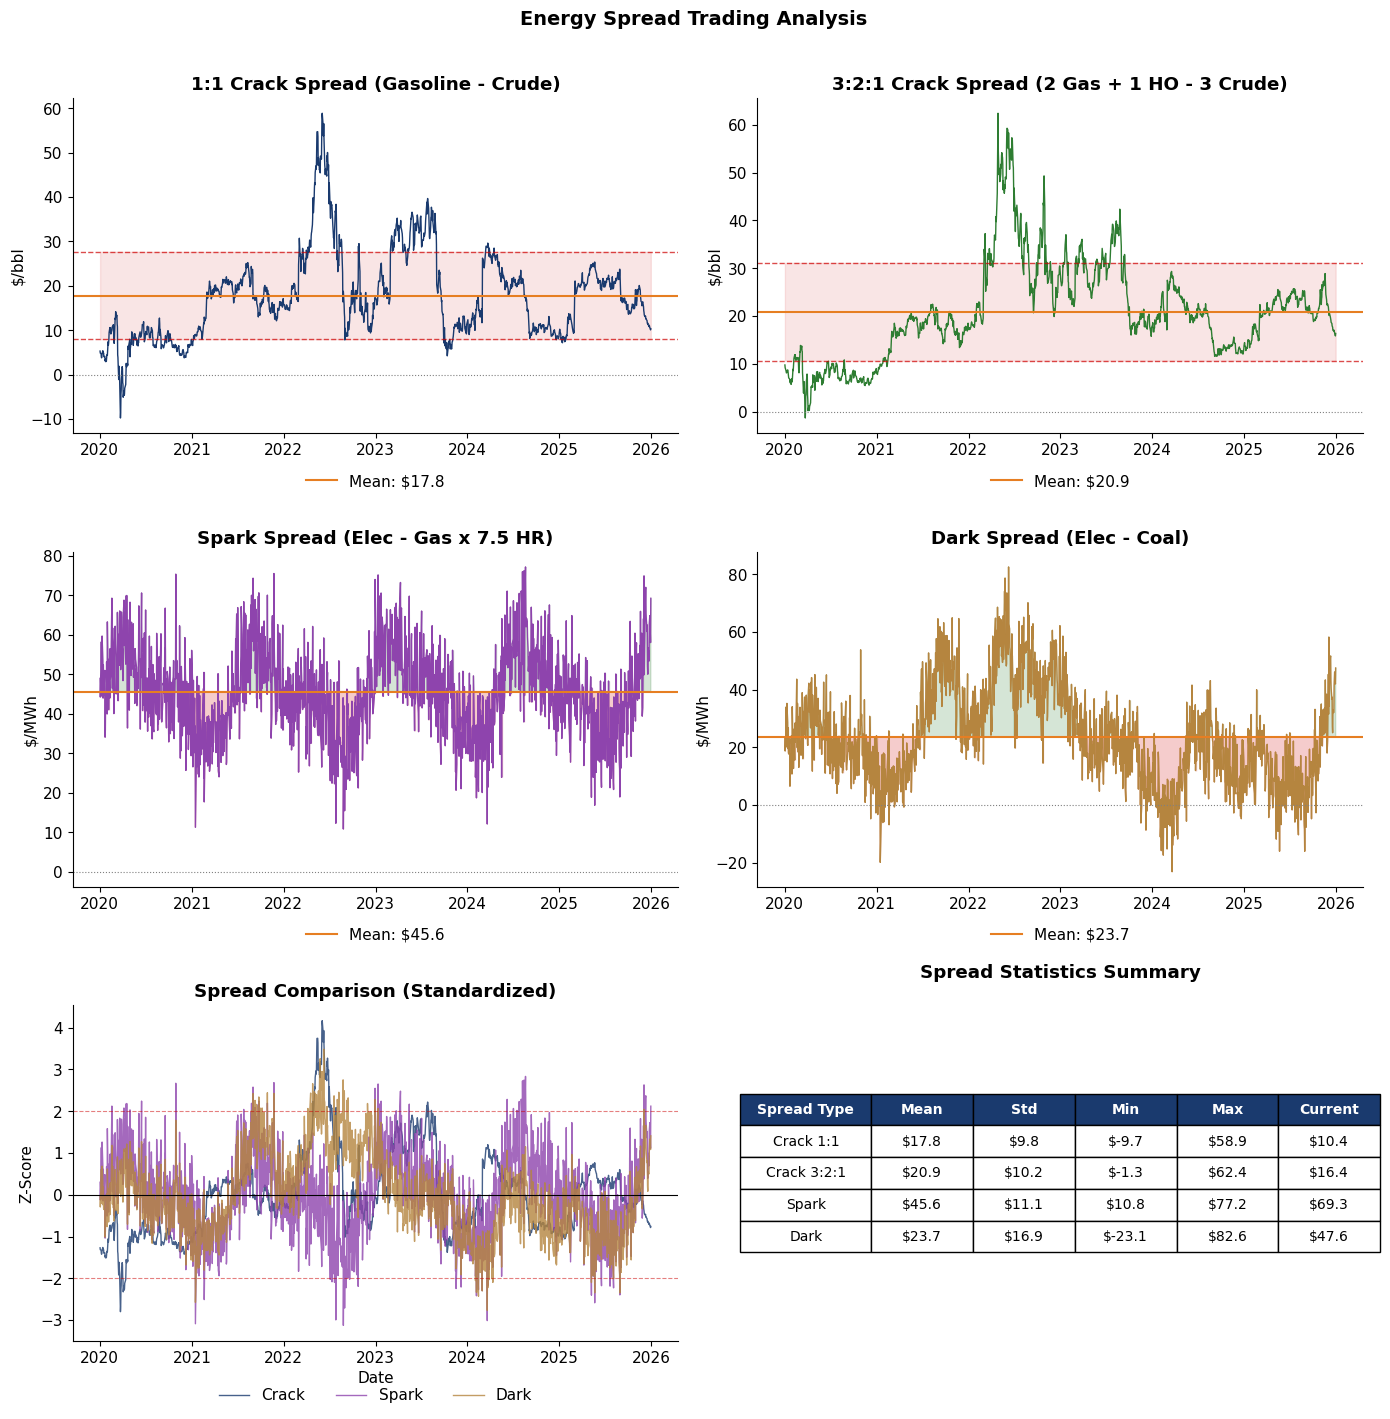

In [7]:
# Create comprehensive 3x2 figure
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Panel 1: 1:1 Crack Spread (Gasoline)
ax = axes[0, 0]
ax.plot(crack_1_1.index, crack_1_1.values, color=COLORS['blue'], linewidth=1)
mean_val = crack_1_1.mean()
std_val = crack_1_1.std()
ax.axhline(mean_val, color=COLORS['orange'], linestyle='-', linewidth=1.5, 
           label=f'Mean: ${mean_val:.1f}')
ax.axhline(mean_val + std_val, color=COLORS['red'], linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(mean_val - std_val, color=COLORS['red'], linestyle='--', linewidth=1, alpha=0.7)
ax.fill_between(crack_1_1.index, mean_val - std_val, mean_val + std_val, 
                alpha=0.1, color=COLORS['red'])
ax.axhline(0, color=COLORS['gray'], linestyle=':', linewidth=0.8)
ax.set_ylabel('$/bbl')
ax.set_title('1:1 Crack Spread (Gasoline - Crude)', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)

# Panel 2: 3:2:1 Crack Spread
ax = axes[0, 1]
ax.plot(crack_3_2_1.index, crack_3_2_1.values, color=COLORS['green'], linewidth=1)
mean_val = crack_3_2_1.mean()
std_val = crack_3_2_1.std()
ax.axhline(mean_val, color=COLORS['orange'], linestyle='-', linewidth=1.5,
           label=f'Mean: ${mean_val:.1f}')
ax.axhline(mean_val + std_val, color=COLORS['red'], linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(mean_val - std_val, color=COLORS['red'], linestyle='--', linewidth=1, alpha=0.7)
ax.fill_between(crack_3_2_1.index, mean_val - std_val, mean_val + std_val,
                alpha=0.1, color=COLORS['red'])
ax.axhline(0, color=COLORS['gray'], linestyle=':', linewidth=0.8)
ax.set_ylabel('$/bbl')
ax.set_title('3:2:1 Crack Spread (2 Gas + 1 HO - 3 Crude)', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)

# Panel 3: Spark Spread
ax = axes[1, 0]
ax.plot(spark_spread.index, spark_spread.values, color=COLORS['purple'], linewidth=1)
mean_val = spark_spread.mean()
std_val = spark_spread.std()
ax.axhline(mean_val, color=COLORS['orange'], linestyle='-', linewidth=1.5,
           label=f'Mean: ${mean_val:.1f}')
ax.fill_between(spark_spread.index, spark_spread.values, mean_val,
                where=(spark_spread.values > mean_val), alpha=0.2, color=COLORS['green'])
ax.fill_between(spark_spread.index, spark_spread.values, mean_val,
                where=(spark_spread.values < mean_val), alpha=0.2, color=COLORS['red'])
ax.axhline(0, color=COLORS['gray'], linestyle=':', linewidth=0.8)
ax.set_ylabel('$/MWh')
ax.set_title(f'Spark Spread (Elec - Gas x {heat_rate} HR)', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)

# Panel 4: Dark Spread
ax = axes[1, 1]
ax.plot(dark_spread.index, dark_spread.values, color=COLORS['amber'], linewidth=1)
mean_val = dark_spread.mean()
ax.axhline(mean_val, color=COLORS['orange'], linestyle='-', linewidth=1.5,
           label=f'Mean: ${mean_val:.1f}')
ax.fill_between(dark_spread.index, dark_spread.values, mean_val,
                where=(dark_spread.values > mean_val), alpha=0.2, color=COLORS['green'])
ax.fill_between(dark_spread.index, dark_spread.values, mean_val,
                where=(dark_spread.values < mean_val), alpha=0.2, color=COLORS['red'])
ax.axhline(0, color=COLORS['gray'], linestyle=':', linewidth=0.8)
ax.set_ylabel('$/MWh')
ax.set_title(f'Dark Spread (Elec - Coal)', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), frameon=False)

# Panel 5: Spread Comparison (Normalized)
ax = axes[2, 0]
# Normalize spreads to z-scores for comparison
crack_z = (crack_1_1 - crack_1_1.mean()) / crack_1_1.std()
spark_z = (spark_spread - spark_spread.mean()) / spark_spread.std()
dark_z = (dark_spread - dark_spread.mean()) / dark_spread.std()

ax.plot(crack_z.index, crack_z.values, color=COLORS['blue'], linewidth=1, 
        alpha=0.8, label='Crack')
ax.plot(spark_z.index, spark_z.values, color=COLORS['purple'], linewidth=1,
        alpha=0.8, label='Spark')
ax.plot(dark_z.index, dark_z.values, color=COLORS['amber'], linewidth=1,
        alpha=0.8, label='Dark')
ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax.axhline(2, color=COLORS['red'], linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(-2, color=COLORS['red'], linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Z-Score')
ax.set_xlabel('Date')
ax.set_title('Spread Comparison (Standardized)', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=3)

# Panel 6: Spread Statistics Box
ax = axes[2, 1]
ax.axis('off')

# Create summary table
table_data = [
    ['Spread Type', 'Mean', 'Std', 'Min', 'Max', 'Current'],
    ['Crack 1:1', f'${crack_1_1.mean():.1f}', f'${crack_1_1.std():.1f}', 
     f'${crack_1_1.min():.1f}', f'${crack_1_1.max():.1f}', f'${crack_1_1.iloc[-1]:.1f}'],
    ['Crack 3:2:1', f'${crack_3_2_1.mean():.1f}', f'${crack_3_2_1.std():.1f}',
     f'${crack_3_2_1.min():.1f}', f'${crack_3_2_1.max():.1f}', f'${crack_3_2_1.iloc[-1]:.1f}'],
    ['Spark', f'${spark_spread.mean():.1f}', f'${spark_spread.std():.1f}',
     f'${spark_spread.min():.1f}', f'${spark_spread.max():.1f}', f'${spark_spread.iloc[-1]:.1f}'],
    ['Dark', f'${dark_spread.mean():.1f}', f'${dark_spread.std():.1f}',
     f'${dark_spread.min():.1f}', f'${dark_spread.max():.1f}', f'${dark_spread.iloc[-1]:.1f}'],
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 loc='center', cellLoc='center',
                 colColours=[COLORS['blue']]*6,
                 colWidths=[0.18, 0.14, 0.14, 0.14, 0.14, 0.14])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Color header text white
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(color='white', fontweight='bold')

ax.set_title('Spread Statistics Summary', fontweight='bold', pad=20)

fig.suptitle('Energy Spread Trading Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig(fig, 'spread_trading.pdf')
plt.show()

In [8]:
# Educational summary
print("=" * 70)
print("ENERGY SPREAD TRADING CONCEPTS")
print("=" * 70)

print("\nCRACK SPREAD (Refining Margin):")
print("  Formula: Product Price - Crude Price")
print("  1:1 Spread: 1 bbl product - 1 bbl crude")
print("  3:2:1 Spread: (2 bbl gasoline + 1 bbl heating oil - 3 bbl crude) / 3")
print("  Interpretation: Positive = Refining profitable")

print("\nSPARK SPREAD (Gas Power Plant Margin):")
print("  Formula: Electricity Price - Gas Price x Heat Rate")
print(f"  Typical Heat Rate: {heat_rate} MMBtu/MWh (CCGT)")
print("  Interpretation: Positive = Gas generation profitable")

print("\nDARK SPREAD (Coal Power Plant Margin):")
print("  Formula: Electricity Price - Coal Cost per MWh")
print(f"  Typical Heat Rate: {coal_heat_rate} MMBtu/MWh (Coal plant)")
print("  Interpretation: Positive = Coal generation profitable")

print("\nTRADING STRATEGIES:")
print("  - Mean reversion: Trade when spread deviates > 2 std")
print("  - Seasonal patterns: Crack spreads widen in summer (driving season)")
print("  - Clean spark spread: Includes carbon cost adjustment")

ENERGY SPREAD TRADING CONCEPTS

CRACK SPREAD (Refining Margin):
  Formula: Product Price - Crude Price
  1:1 Spread: 1 bbl product - 1 bbl crude
  3:2:1 Spread: (2 bbl gasoline + 1 bbl heating oil - 3 bbl crude) / 3
  Interpretation: Positive = Refining profitable

SPARK SPREAD (Gas Power Plant Margin):
  Formula: Electricity Price - Gas Price x Heat Rate
  Typical Heat Rate: 7.5 MMBtu/MWh (CCGT)
  Interpretation: Positive = Gas generation profitable

DARK SPREAD (Coal Power Plant Margin):
  Formula: Electricity Price - Coal Cost per MWh
  Typical Heat Rate: 10.5 MMBtu/MWh (Coal plant)
  Interpretation: Positive = Coal generation profitable

TRADING STRATEGIES:
  - Mean reversion: Trade when spread deviates > 2 std
  - Seasonal patterns: Crack spreads widen in summer (driving season)
  - Clean spark spread: Includes carbon cost adjustment
